# RAF-DB Full Graphormer-Lite Landmark Experiment

Self-contained Colab notebook for **Graphormer-lite only** training on precomputed MediaPipe RAF-DB landmarks. It keeps the same pinned package setup as the legacy notebook, but replaces the previous simplified transformer with a fuller graph-aware implementation: typed FaceMesh graph edges, region/action embeddings, learned structural attention biases, dynamic distance bias, landmark-space augmentation, cosine warmup, CE/Focal loss variants, and durable experiment logs.

Outputs are written under `rafdb_graphormer_lite_full_run/`.


## Setup

Run this first. If packages are repaired or installed, Colab will restart the runtime. After reconnecting, run the notebook again from the top.


In [ ]:
# Colab 2025.07 setup with uv for legacy MediaPipe Solutions API.
# Run this cell first. If it changes binary packages, it restarts the runtime automatically.

from __future__ import annotations

import os
import shutil
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

# Set True only if you want to repair/reinstall the pinned packages again.
FORCE_REINSTALL = False
RESTART_AFTER_INSTALL = True

# Important:
# - MediaPipe 0.10.18 keeps the legacy mp.solutions.face_mesh API used below.
# - MediaPipe 0.10.18 requires NumPy < 2, so Colab's NumPy 2.x must be replaced.
# - NumPy 1.26.4 is used instead of 1.23.5 because it is newer and works with
#   pandas/scipy/sklearn wheels on Python 3.11.
# - Torch is intentionally NOT pinned here. Keep Colab's preinstalled torch/CUDA build.
PINNED_PACKAGES = [
    "numpy==1.26.4",
    "pandas==2.2.3",
    "scipy==1.14.1",
    "scikit-learn==1.5.2",
    "pyarrow==21.0.0",
    "pillow==10.4.0",
    "protobuf==4.25.5",
    "mediapipe==0.10.18",
    "datasets==4.8.5",
    "huggingface-hub==1.16.1",
    "hf-transfer==0.1.8",
    "tqdm==4.66.5",
    "xgboost==2.1.1",
    "matplotlib==3.9.2",
    "seaborn==0.13.2",
]

# Reinstall binary packages that commonly cause ABI mismatches after partial installs.
REINSTALL_PACKAGES = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "pyarrow",
    "pillow",
    "protobuf",
    "mediapipe",
    "matplotlib",
]

PACKAGE_IMPORT_NAMES = {
    "scikit-learn": "sklearn",
    "pillow": "PIL",
    "huggingface-hub": "huggingface_hub",
    "hf-transfer": "hf_transfer",
}

def dist_name(requirement: str) -> str:
    return requirement.split("==", 1)[0]

def expected_version(requirement: str) -> str:
    return requirement.split("==", 1)[1]

def installed_version(distribution_name: str) -> str | None:
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        return None

expected = {dist_name(req): expected_version(req) for req in PINNED_PACKAGES}
current = {name: installed_version(name) for name in expected}

needs_install = FORCE_REINSTALL or any(current[name] != expected[name] for name in expected)

print("Python:", sys.version)
print("Package status:")
for name in expected:
    marker = "OK" if current[name] == expected[name] else "CHANGE"
    print(f"  {name:18s} installed={current[name]!s:12s} expected={expected[name]:8s} {marker}")

if not needs_install:
    print("\nEnvironment already matches the pinned package set. Continuing without reinstall.")
else:
    uv_bin = shutil.which("uv")
    if uv_bin is None:
        print("\nInstalling uv with the official standalone installer...")
        subprocess.check_call("curl -LsSf https://astral.sh/uv/install.sh | sh", shell=True)
        candidate_paths = [
            os.path.expanduser("~/.local/bin/uv"),
            "/root/.local/bin/uv",
        ]
        uv_bin = next((p for p in candidate_paths if os.path.exists(p)), None)
        if uv_bin is None:
            os.environ["PATH"] = os.path.expanduser("~/.local/bin") + os.pathsep + os.environ.get("PATH", "")
            uv_bin = shutil.which("uv")
        if uv_bin is None:
            raise RuntimeError("uv was installed, but the uv executable was not found on PATH.")

    print(f"\nUsing uv: {uv_bin}")

    cmd = [
        uv_bin,
        "pip",
        "install",
        "--system",
        "--upgrade",
    ]

    for package_name in REINSTALL_PACKAGES:
        cmd.extend(["--reinstall-package", package_name])

    cmd.extend(PINNED_PACKAGES)

    print("\nRunning:")
    print(" ".join(cmd))
    subprocess.check_call(cmd)

    print("\nPackage installation finished.")
    if RESTART_AFTER_INSTALL:
        print("Restarting Colab runtime now. After reconnecting, run the notebook from the top again.", flush=True)
        os.kill(os.getpid(), 9)


Python: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]
Package status:
  numpy              installed=1.26.3       expected=1.26.4   CHANGE
  pandas             installed=None         expected=2.2.3    CHANGE
  scipy              installed=None         expected=1.14.1   CHANGE
  scikit-learn       installed=None         expected=1.5.2    CHANGE
  pyarrow            installed=None         expected=21.0.0   CHANGE
  pillow             installed=10.2.0       expected=10.4.0   CHANGE
  protobuf           installed=None         expected=4.25.5   CHANGE
  mediapipe          installed=None         expected=0.10.18  CHANGE
  datasets           installed=None         expected=4.8.5    CHANGE
  huggingface-hub    installed=None         expected=1.16.1   CHANGE
  hf-transfer        installed=None         expected=0.1.8    CHANGE
  tqdm               installed=None         expected=4.66.5   CHANGE
  xgboost            installed=None         expected=2.1.1    CHANGE
  matplotlib         install

downloading uv 0.11.16 x86_64-unknown-linux-gnu


installing to /root/.local/bin
  uv
  uvx
everything's installed!

To add $HOME/.local/bin to your PATH, either restart your shell or run:

    source $HOME/.local/bin/env (sh, bash, zsh)
    source $HOME/.local/bin/env.fish (fish)

Using uv: /root/.local/bin/uv

Running:
/root/.local/bin/uv pip install --system --upgrade --reinstall-package numpy --reinstall-package pandas --reinstall-package scipy --reinstall-package scikit-learn --reinstall-package pyarrow --reinstall-package pillow --reinstall-package protobuf --reinstall-package mediapipe --reinstall-package matplotlib numpy==1.26.4 pandas==2.2.3 scipy==1.14.1 scikit-learn==1.5.2 pyarrow==21.0.0 pillow==10.4.0 protobuf==4.25.5 mediapipe==0.10.18 datasets==4.8.5 huggingface-hub==1.16.1 hf-transfer==0.1.8 tqdm==4.66.5 xgboost==2.1.1 matplotlib==3.9.2 seaborn==0.13.2


Using Python 3.11.10 environment at: /usr
Resolved 72 packages in 563ms
Prepared 71 packages in 8.55s
Uninstalled 21 packages in 408ms


## Verify Environment

This must pass before loading data or training.


In [1]:
# Environment sanity check.
# Run after the setup cell has completed and the runtime has restarted.

import sys

import mediapipe as mp
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy
import sklearn
import torch

print("Python:", sys.version)
print("MediaPipe:", mp.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyArrow:", pa.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Hard sanity checks for the parts this notebook needs.
_ = np.random.RandomState(42)
_ = pd.DataFrame({"x": [1, 2, 3]})
_ = mp.solutions.face_mesh.FACEMESH_TESSELATION
_ = mp.solutions.face_mesh.FACEMESH_CONTOURS
_ = mp.solutions.face_mesh.FACEMESH_IRISES

print("Sanity check passed.")


Python: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]
MediaPipe: 0.10.18
NumPy: 1.26.4
Pandas: 2.2.3
PyArrow: 21.0.0
SciPy: 1.14.1
Scikit-learn: 1.5.2
Torch: 2.4.1+cu124
CUDA available: True
Sanity check passed.


## Optional Hugging Face Auth

If `load_dataset` cannot access the dataset in your runtime, uncomment and run the login line.


In [ ]:
# !hf auth login


## Imports And Experiment Config

Normal run controls live here: seeds, sample cap, enabled Graphormer-lite variants, loss/weighting, augmentation, and model sizes.


In [2]:
from __future__ import annotations

from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Optional
import copy
import datetime as dt
import json
import math
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message="IProgress not found.*")
pd.set_option("display.max_columns", 200)
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")

FACE_MESH = mp.solutions.face_mesh

HF_DATASET_ID = "Pelmeshek/raf-db-7emotions-mediapipe-768"
RUN_DIR = Path("rafdb_graphormer_lite_full_run")
RESULTS_DIR = RUN_DIR / "results"
EXPERIMENTS_DIR = RUN_DIR / "experiments"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
for path_obj in (RESULTS_DIR, EXPERIMENTS_DIR, CHECKPOINT_DIR):
    path_obj.mkdir(parents=True, exist_ok=True)

SEED = 42
RUN_SEEDS = [42]
MAX_SAMPLES_PER_SPLIT = None  # set e.g. 2048 for debugging; keep None for full splits
LANDMARK_COLUMN = "landmarks_stable_eye_norm"
LANDMARK_IMAGE_SIZE = 768
EXPECTED_SPLITS = ("train", "val", "test")
NUM_WORKERS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

TARGET_LABELS = ["anger", "disgust", "fear", "happiness", "sadness", "surprise", "neutral"]
TARGET_LABEL_TO_ID = {name: idx for idx, name in enumerate(TARGET_LABELS)}
ID_TO_TARGET_LABEL = {idx: name for name, idx in TARGET_LABEL_TO_ID.items()}
NUM_CLASSES = len(TARGET_LABELS)
LANDMARK_COUNT = 478

# Optional sanity check. It should overfit a tiny subset if the model and gradients are wired correctly.
RUN_OVERFIT_SANITY = False

BASE_AUGMENT_CONFIG = {
    "coord_noise_std": 0.005,
    "z_noise_std": 0.003,
    "scale_jitter": 0.03,
    "rotation_jitter_degrees": 5.0,
    "landmark_dropout_prob": 0.02,
    "region_dropout_prob": 0.05,
}

# Graphormer-lite-only architecture sweep. No MLP/XGBoost/classical baselines are trained here.
# Enable the large candidate after the small/medium candidates establish a stable training curve.
EXPERIMENTS = [
    # {
    #     "name": "gformer_s_ce_sqrtw_geom",
    #     "enabled": True,
    #     "model": {
    #         "d_model": 128,
    #         "num_layers": 3,
    #         "num_heads": 4,
    #         "ffn_dim": 256,
    #         "dropout": 0.20,
    #         "pooling": "cls_mean",
    #         "use_geometry": True,
    #         "geometry_dim": 21,
    #         "head_hidden_dim": 256,
    #     },
    #     "train": {
    #         "batch_size": 64,
    #         "lr": 3e-4,
    #         "weight_decay": 1e-2,
    #         "label_smoothing": 0.05,
    #         "loss_kind": "ce",
    #         "class_weight_power": 0.50,
    #         "max_epochs": 80,
    #         "warmup_epochs": 5,
    #         "early_stopping_patience": 15,
    #         "max_grad_norm": 1.0,
    #         "augment_config": BASE_AUGMENT_CONFIG,
    #     },
    # },
    # {
    #     "name": "gformer_m_ce_sqrtw_geom",
    #     "enabled": True,
    #     "model": {
    #         "d_model": 192,
    #         "num_layers": 4,
    #         "num_heads": 6,
    #         "ffn_dim": 384,
    #         "dropout": 0.25,
    #         "pooling": "cls_mean",
    #         "use_geometry": True,
    #         "geometry_dim": 21,
    #         "head_hidden_dim": 384,
    #     },
    #     "train": {
    #         "batch_size": 48,
    #         "lr": 2e-4,
    #         "weight_decay": 1e-2,
    #         "label_smoothing": 0.05,
    #         "loss_kind": "ce",
    #         "class_weight_power": 0.50,
    #         "max_epochs": 90,
    #         "warmup_epochs": 5,
    #         "early_stopping_patience": 18,
    #         "max_grad_norm": 1.0,
    #         "augment_config": BASE_AUGMENT_CONFIG,
    #     },
    # },
    {
        "name": "gformer_m_focal_sqrtw_geom",
        "enabled": True,
        "model": {
            "d_model": 192,
            "num_layers": 4,
            "num_heads": 6,
            "ffn_dim": 384,
            "dropout": 0.25,
            "pooling": "cls_mean_max",
            "use_geometry": True,
            "geometry_dim": 21,
            "head_hidden_dim": 384,
        },
        "train": {
            "batch_size": 48,
            "lr": 2e-4,
            "weight_decay": 1e-2,
            "label_smoothing": 0.0,
            "loss_kind": "focal",
            "focal_gamma": 1.5,
            "class_weight_power": 0.50,
            "max_epochs": 90,
            "warmup_epochs": 5,
            "early_stopping_patience": 18,
            "max_grad_norm": 1.0,
            "augment_config": BASE_AUGMENT_CONFIG,
        },
    },
    {
        "name": "gformer_l_ce_lightw_geom",
        "enabled": False,
        "model": {
            "d_model": 256,
            "num_layers": 4,
            "num_heads": 8,
            "ffn_dim": 512,
            "dropout": 0.30,
            "pooling": "cls_mean_max",
            "use_geometry": True,
            "geometry_dim": 21,
            "head_hidden_dim": 512,
        },
        "train": {
            "batch_size": 32,
            "lr": 1.5e-4,
            "weight_decay": 1e-2,
            "label_smoothing": 0.05,
            "loss_kind": "ce",
            "class_weight_power": 0.35,
            "max_epochs": 100,
            "warmup_epochs": 6,
            "early_stopping_patience": 20,
            "max_grad_norm": 1.0,
            "augment_config": BASE_AUGMENT_CONFIG,
        },
    },
]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = False

set_seed(SEED)
print("device:", DEVICE)
print("mediapipe version:", mp.__version__)
print("results dir:", RESULTS_DIR.resolve())
print("enabled experiments:", [cfg["name"] for cfg in EXPERIMENTS if cfg.get("enabled", True)])


device: cuda
mediapipe version: 0.10.18
results dir: /workspace/rafdb_graphormer_lite_full_run/results
enabled experiments: ['gformer_s_ce_sqrtw_geom', 'gformer_m_ce_sqrtw_geom', 'gformer_m_focal_sqrtw_geom']


## Load Precomputed Landmark Dataset

The notebook uses the published `train/val/test` splits and trains only on rows where landmark extraction succeeded.


In [3]:
dataset_dict = load_dataset(HF_DATASET_ID)
split_names = tuple(dataset_dict.keys())
missing_splits = sorted(set(EXPECTED_SPLITS) - set(split_names))
if missing_splits:
    raise ValueError(f"Missing expected splits: {missing_splits}; found {split_names}")

split_datasets = {}
for split_name in EXPECTED_SPLITS:
    split_ds = dataset_dict[split_name]
    if MAX_SAMPLES_PER_SPLIT is not None:
        split_ds = split_ds.select(range(min(int(MAX_SAMPLES_PER_SPLIT), len(split_ds))))
    split_datasets[split_name] = split_ds

label_names = list(split_datasets["train"].features["label"].names)
if label_names != TARGET_LABELS:
    raise ValueError(f"Unexpected label order: {label_names}")

KEEP_COLUMNS = [
    "sample_id",
    "source_index",
    "split",
    "hf_label_id",
    "hf_label_name",
    "label",
    "label_name",
    "mediapipe_image_size",
    "landmark_success",
    "failure_reason",
    LANDMARK_COLUMN,
    "inter_eye_scale",
    "roll_radians",
]

def dataset_split_to_frame(split_name: str) -> pd.DataFrame:
    split_ds = split_datasets[split_name]
    drop_columns = [column for column in split_ds.column_names if column not in KEEP_COLUMNS]
    slim_ds = split_ds.remove_columns(drop_columns) if drop_columns else split_ds
    frame = slim_ds.to_pandas()
    frame["split"] = split_name
    frame["label_id"] = frame["label"].astype(np.int64)
    frame["label_name"] = frame["label_name"].astype(str)
    frame["landmarks_norm"] = frame[LANDMARK_COLUMN]
    return frame

split_frames = {split_name: dataset_split_to_frame(split_name) for split_name in EXPECTED_SPLITS}
all_df = pd.concat([split_frames[split_name] for split_name in EXPECTED_SPLITS], ignore_index=True)
success_df = all_df.loc[all_df["landmark_success"]].copy().reset_index(drop=True)
failure_df = all_df.loc[~all_df["landmark_success"]].copy().reset_index(drop=True)

coverage_rows = []
for split_name in EXPECTED_SPLITS:
    split_frame = all_df.loc[all_df["split"] == split_name]
    success_count = int(split_frame["landmark_success"].sum())
    total_count = int(len(split_frame))
    coverage_rows.append({
        "split": split_name,
        "success_rows": success_count,
        "failure_rows": total_count - success_count,
        "total_rows": total_count,
        "coverage": float(success_count / max(total_count, 1)),
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage = float(success_df.shape[0] / max(all_df.shape[0], 1))
coverage_by_split = {row["split"]: float(row["coverage"]) for _, row in coverage_df.iterrows()}

for split_name in EXPECTED_SPLITS:
    usable = int((success_df["split"] == split_name).sum())
    if usable == 0:
        raise ValueError(f"No successful landmark rows available for split={split_name}")

print({split_name: len(split_datasets[split_name]) for split_name in EXPECTED_SPLITS})
print("overall usable rows:", len(success_df))
print("overall coverage:", round(coverage, 4))
display(coverage_df)
display(success_df.groupby(["split", "label_name"]).size().unstack(fill_value=0)[TARGET_LABELS])
if len(failure_df) > 0:
    display(failure_df.groupby(["split", "failure_reason"]).size().rename("count").reset_index().sort_values("count", ascending=False).head(20))


README.md:   0%|          | 0.00/2.75k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/110M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/112M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/112M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

...

Generating val split: 0 examples [00:00, ? examples/s]

{'train': 14329, 'val': 3071, 'test': 3071}
overall usable rows: 18078
overall coverage: 0.8831


,split,success_rows,failure_rows,total_rows,coverage
0,train,12679,1650,14329,0.884849
1,val,2679,392,3071,0.872354
2,test,2720,351,3071,0.885705


label_name,anger,disgust,fear,happiness,sadness,surprise,neutral
split,,,,,,,
test,495,112,45,780,299,219,770
train,2327,532,203,3545,1468,1013,3591
val,479,112,41,753,307,217,770


,split,failure_reason,count
1,train,no_face_detected,1650
2,val,no_face_detected,392
0,test,no_face_detected,351


## Prepare Split Tensors

No random re-split is performed here. Validation and test splits remain as published in the dataset.


In [4]:
def stack_landmarks(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[str]]:
    landmarks = np.stack([
        np.asarray(value.tolist() if hasattr(value, "tolist") else value, dtype=np.float32)
        for value in frame["landmarks_norm"].to_list()
    ]).astype(np.float32)
    labels = frame["label_id"].to_numpy(dtype=np.int64)
    sample_ids = frame["sample_id"].astype(str).tolist()
    return landmarks, labels, sample_ids

train_df = success_df.loc[success_df["split"] == "train"].reset_index(drop=True)
val_df = success_df.loc[success_df["split"] == "val"].reset_index(drop=True)
test_df = success_df.loc[success_df["split"] == "test"].reset_index(drop=True)

X_train, y_train, ids_train = stack_landmarks(train_df)
X_val, y_val, ids_val = stack_landmarks(val_df)
X_test, y_test, ids_test = stack_landmarks(test_df)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
display(success_df.groupby(["split", "label_name"]).size().unstack(fill_value=0)[TARGET_LABELS])


X_train: (12679, 478, 3)
X_val: (2679, 478, 3)
X_test: (2720, 478, 3)


label_name,anger,disgust,fear,happiness,sadness,surprise,neutral
split,,,,,,,
test,495,112,45,780,299,219,770
train,2327,532,203,3545,1468,1013,3591
val,479,112,41,753,307,217,770


## Build Full Face Graph Topology

This is the structural part missing from the legacy notebook: anatomical regions, action regions, semantic edge types, symmetry/action/anchor edges, shortest-path buckets, region relations, and degree buckets.


In [5]:
ANATOMICAL_REGION_NAMES = [
    "left_eye", "right_eye", "left_eyebrow", "right_eyebrow", "nose_bridge", "nose_tip",
    "upper_lip_outer", "lower_lip_outer", "upper_lip_inner", "lower_lip_inner",
    "left_mouth_corner", "right_mouth_corner", "jaw_chin", "left_cheek", "right_cheek",
    "face_oval_qc", "other",
]
ANATOMICAL_REGION_TO_ID = {name: idx for idx, name in enumerate(ANATOMICAL_REGION_NAMES)}

ACTION_REGION_NAMES = [
    "eye_openness_left", "eye_openness_right", "brow_raise_left", "brow_raise_right", "brow_furrow",
    "mouth_width", "mouth_opening", "mouth_corner_lift_left", "mouth_corner_lift_right",
    "lip_compression", "jaw_drop", "mouth_asymmetry", "other",
]
ACTION_REGION_TO_ID = {name: idx for idx, name in enumerate(ACTION_REGION_NAMES)}

EDGE_TYPE_NAMES = ["self", "mesh_local", "same_region", "symmetry", "action_pair", "anchor_to_region", "global_non_edge"]
EDGE_TYPE_TO_ID = {name: idx for idx, name in enumerate(EDGE_TYPE_NAMES)}

LEFT_EYE_CORNERS = (33, 133)
RIGHT_EYE_CORNERS = (362, 263)
LEFT_IRIS_INDICES = (468, 469, 470, 471, 472)
RIGHT_IRIS_INDICES = (473, 474, 475, 476, 477)

OUTER_UPPER_LIP = {61, 185, 40, 39, 37, 0, 267, 269, 270, 409, 291}
OUTER_LOWER_LIP = {61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291}
INNER_UPPER_LIP = {78, 191, 80, 81, 82, 13, 312, 311, 310, 415, 308}
INNER_LOWER_LIP = {78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308}
LEFT_MOUTH_CORNER = {61, 146, 91, 185}
RIGHT_MOUTH_CORNER = {291, 375, 321, 409}
NOSE_BRIDGE = {6, 168, 197, 195, 5, 4}
NOSE_TIP = {1, 2, 98, 327, 97, 326}
JAW_CHIN = {152, 148, 176, 149, 150, 136, 172, 58, 132, 361, 288, 397, 365, 379, 378, 400, 377}
LEFT_CHEEK = {205, 187, 147, 213, 192, 214, 135, 138, 215, 177, 137, 116, 123}
RIGHT_CHEEK = {425, 411, 376, 433, 416, 434, 364, 367, 435, 401, 366, 345, 352}

ACTION_REGION_SPEC = {
    "eye_openness_left": {159, 145, 160, 144, 158, 153},
    "eye_openness_right": {386, 374, 385, 380, 387, 373},
    "brow_raise_left": {70, 63, 105, 66, 107},
    "brow_raise_right": {336, 296, 334, 293, 300},
    "brow_furrow": {55, 65, 52, 53, 46, 285, 295, 282, 283, 276},
    "mouth_width": {61, 291, 78, 308},
    "mouth_opening": {13, 14, 0, 17, 82, 87, 312, 317},
    "mouth_corner_lift_left": LEFT_MOUTH_CORNER,
    "mouth_corner_lift_right": RIGHT_MOUTH_CORNER,
    "lip_compression": INNER_UPPER_LIP | INNER_LOWER_LIP,
    "jaw_drop": {152, 17, 13, 14, 172, 397},
    "mouth_asymmetry": LEFT_MOUTH_CORNER | RIGHT_MOUTH_CORNER | {13, 14},
}

SYMMETRIC_REGION_PAIRS = {
    "left_eye": "right_eye", "right_eye": "left_eye",
    "left_eyebrow": "right_eyebrow", "right_eyebrow": "left_eyebrow",
    "left_mouth_corner": "right_mouth_corner", "right_mouth_corner": "left_mouth_corner",
    "left_cheek": "right_cheek", "right_cheek": "left_cheek",
}

SYMMETRY_NODE_PAIRS = [
    (33, 263), (133, 362), (159, 386), (145, 374), (70, 300), (105, 334),
    (66, 296), (107, 336), (61, 291), (78, 308), (146, 375), (91, 321),
    (205, 425), (123, 352), (50, 280), (58, 288),
]

ACTION_NODE_PAIRS = [
    (61, 291), (78, 308), (13, 14), (0, 17), (82, 87), (312, 317),
    (159, 145), (386, 374), (105, 159), (334, 386), (70, 33), (300, 263),
    (1, 13), (1, 14), (152, 17), (205, 61), (425, 291),
]

REGION_ANCHORS = {
    "left_eye": 33, "right_eye": 263, "left_eyebrow": 105, "right_eyebrow": 334,
    "nose_bridge": 6, "nose_tip": 1, "upper_lip_outer": 0, "lower_lip_outer": 17,
    "upper_lip_inner": 13, "lower_lip_inner": 14, "left_mouth_corner": 61,
    "right_mouth_corner": 291, "jaw_chin": 152, "left_cheek": 205, "right_cheek": 425,
}

@dataclass(frozen=True)
class FaceGraphTopology:
    num_nodes: int
    edge_index: torch.LongTensor
    adjacency: torch.FloatTensor
    adjacency_mask: torch.BoolTensor
    normalized_adjacency: torch.FloatTensor
    shortest_path: torch.LongTensor
    spatial_bucket: torch.LongTensor
    edge_type: torch.LongTensor
    region_ids: torch.LongTensor
    action_region_ids: torch.LongTensor
    expression_node_mask: torch.BoolTensor
    degree_bucket: torch.LongTensor
    max_spatial_bucket: int
    max_degree_bucket: int
    edge_type_names: list[str]
    region_names: list[str]
    action_region_names: list[str]

def _node_set_from_edges(edge_iterable) -> set[int]:
    out = set()
    for left, right in edge_iterable:
        out.add(int(left)); out.add(int(right))
    return out

def _safe_add_nodes(target: dict[str, set[int]], region_name: str, nodes) -> None:
    target[region_name].update(int(node) for node in nodes if 0 <= int(node) < LANDMARK_COUNT)

def build_region_maps() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    anatomical_nodes = {name: set() for name in ANATOMICAL_REGION_NAMES}
    _safe_add_nodes(anatomical_nodes, "left_eye", _node_set_from_edges(getattr(FACE_MESH, "FACEMESH_LEFT_EYE", [])))
    _safe_add_nodes(anatomical_nodes, "left_eye", LEFT_IRIS_INDICES)
    _safe_add_nodes(anatomical_nodes, "right_eye", _node_set_from_edges(getattr(FACE_MESH, "FACEMESH_RIGHT_EYE", [])))
    _safe_add_nodes(anatomical_nodes, "right_eye", RIGHT_IRIS_INDICES)
    _safe_add_nodes(anatomical_nodes, "left_eyebrow", _node_set_from_edges(getattr(FACE_MESH, "FACEMESH_LEFT_EYEBROW", [])))
    _safe_add_nodes(anatomical_nodes, "right_eyebrow", _node_set_from_edges(getattr(FACE_MESH, "FACEMESH_RIGHT_EYEBROW", [])))
    _safe_add_nodes(anatomical_nodes, "nose_bridge", NOSE_BRIDGE)
    _safe_add_nodes(anatomical_nodes, "nose_tip", NOSE_TIP)
    _safe_add_nodes(anatomical_nodes, "upper_lip_outer", OUTER_UPPER_LIP)
    _safe_add_nodes(anatomical_nodes, "lower_lip_outer", OUTER_LOWER_LIP)
    _safe_add_nodes(anatomical_nodes, "upper_lip_inner", INNER_UPPER_LIP)
    _safe_add_nodes(anatomical_nodes, "lower_lip_inner", INNER_LOWER_LIP)
    _safe_add_nodes(anatomical_nodes, "left_mouth_corner", LEFT_MOUTH_CORNER)
    _safe_add_nodes(anatomical_nodes, "right_mouth_corner", RIGHT_MOUTH_CORNER)
    _safe_add_nodes(anatomical_nodes, "jaw_chin", JAW_CHIN)
    _safe_add_nodes(anatomical_nodes, "left_cheek", LEFT_CHEEK)
    _safe_add_nodes(anatomical_nodes, "right_cheek", RIGHT_CHEEK)
    _safe_add_nodes(anatomical_nodes, "face_oval_qc", _node_set_from_edges(getattr(FACE_MESH, "FACEMESH_FACE_OVAL", [])))

    anatomical_ids = np.full(LANDMARK_COUNT, ANATOMICAL_REGION_TO_ID["other"], dtype=np.int64)
    anatomical_priority = [name for name in ANATOMICAL_REGION_NAMES if name != "other"]
    for region_name in anatomical_priority:
        region_id = ANATOMICAL_REGION_TO_ID[region_name]
        for node in anatomical_nodes[region_name]:
            anatomical_ids[node] = region_id

    action_ids = np.full(LANDMARK_COUNT, ACTION_REGION_TO_ID["other"], dtype=np.int64)
    for action_name, nodes in ACTION_REGION_SPEC.items():
        action_id = ACTION_REGION_TO_ID[action_name]
        for node in nodes:
            if 0 <= node < LANDMARK_COUNT:
                action_ids[node] = action_id

    expression_mask = np.logical_and(
        anatomical_ids != ANATOMICAL_REGION_TO_ID["face_oval_qc"],
        anatomical_ids != ANATOMICAL_REGION_TO_ID["other"],
    )
    return anatomical_ids, action_ids, expression_mask.astype(bool)

def _build_sparse_edges(anatomical_ids: np.ndarray) -> set[tuple[int, int, int]]:
    edges: set[tuple[int, int, int]] = set()
    for edge_source in (getattr(FACE_MESH, "FACEMESH_TESSELATION", []), getattr(FACE_MESH, "FACEMESH_CONTOURS", []), getattr(FACE_MESH, "FACEMESH_IRISES", [])):
        for left, right in edge_source:
            a, b = int(left), int(right)
            if a == b or a >= LANDMARK_COUNT or b >= LANDMARK_COUNT:
                continue
            edges.add((a, b, EDGE_TYPE_TO_ID["mesh_local"]))
            edges.add((b, a, EDGE_TYPE_TO_ID["mesh_local"]))

    for region_name, region_id in ANATOMICAL_REGION_TO_ID.items():
        if region_name in {"face_oval_qc", "other"}:
            continue
        nodes = np.where(anatomical_ids == region_id)[0].tolist()
        for left in nodes:
            for right in nodes:
                if left != right:
                    edges.add((left, right, EDGE_TYPE_TO_ID["same_region"]))

    for left, right in SYMMETRY_NODE_PAIRS:
        if 0 <= left < LANDMARK_COUNT and 0 <= right < LANDMARK_COUNT:
            edges.add((left, right, EDGE_TYPE_TO_ID["symmetry"]))
            edges.add((right, left, EDGE_TYPE_TO_ID["symmetry"]))

    for left, right in ACTION_NODE_PAIRS:
        if 0 <= left < LANDMARK_COUNT and 0 <= right < LANDMARK_COUNT:
            edges.add((left, right, EDGE_TYPE_TO_ID["action_pair"]))
            edges.add((right, left, EDGE_TYPE_TO_ID["action_pair"]))

    for region_name, anchor in REGION_ANCHORS.items():
        region_id = ANATOMICAL_REGION_TO_ID[region_name]
        nodes = np.where(anatomical_ids == region_id)[0]
        for node in nodes:
            if int(node) == int(anchor):
                continue
            edges.add((int(anchor), int(node), EDGE_TYPE_TO_ID["anchor_to_region"]))
            edges.add((int(node), int(anchor), EDGE_TYPE_TO_ID["anchor_to_region"]))

    for node in range(LANDMARK_COUNT):
        edges.add((node, node, EDGE_TYPE_TO_ID["self"]))
    return edges

def _normalize_adjacency(adjacency: torch.FloatTensor) -> torch.FloatTensor:
    degree = adjacency.sum(dim=1)
    inv_sqrt = torch.pow(torch.clamp(degree, min=1e-6), -0.5)
    return torch.diag(inv_sqrt) @ adjacency @ torch.diag(inv_sqrt)

def build_face_graph_topology(max_spatial_bucket: int = 12) -> FaceGraphTopology:
    anatomical_ids, action_ids, expression_mask = build_region_maps()
    typed_edges = _build_sparse_edges(anatomical_ids)

    adjacency = torch.zeros((LANDMARK_COUNT, LANDMARK_COUNT), dtype=torch.float32)
    edge_type = np.full((LANDMARK_COUNT, LANDMARK_COUNT), EDGE_TYPE_TO_ID["global_non_edge"], dtype=np.int64)
    for left, right, edge_type_id in typed_edges:
        adjacency[left, right] = 1.0
        edge_type[left, right] = min(edge_type[left, right], edge_type_id)

    adjacency_for_shortest_path = adjacency.clone()
    adjacency_for_shortest_path.fill_diagonal_(0.0)
    shortest = shortest_path(csr_matrix(adjacency_for_shortest_path.numpy()), directed=False, unweighted=True)
    shortest = np.asarray(shortest)
    shortest[np.isinf(shortest)] = float(max_spatial_bucket)
    shortest = np.clip(shortest, 0, max_spatial_bucket).astype(np.int64)

    degree = adjacency_for_shortest_path.sum(dim=1).to(torch.long)
    max_degree_bucket = int(max(8, int(degree.max().item()) if degree.numel() else 8))
    degree_bucket = torch.clamp(degree, 0, max_degree_bucket)
    adjacency_mask = adjacency > 0
    edge_index = torch.nonzero(adjacency_mask, as_tuple=False).t().contiguous()
    return FaceGraphTopology(
        num_nodes=LANDMARK_COUNT,
        edge_index=edge_index,
        adjacency=adjacency,
        adjacency_mask=adjacency_mask,
        normalized_adjacency=_normalize_adjacency(adjacency),
        shortest_path=torch.from_numpy(shortest).long(),
        spatial_bucket=torch.from_numpy(shortest).long(),
        edge_type=torch.from_numpy(edge_type).long(),
        region_ids=torch.from_numpy(anatomical_ids).long(),
        action_region_ids=torch.from_numpy(action_ids).long(),
        expression_node_mask=torch.from_numpy(expression_mask).bool(),
        degree_bucket=degree_bucket.long(),
        max_spatial_bucket=int(max_spatial_bucket),
        max_degree_bucket=int(max_degree_bucket),
        edge_type_names=EDGE_TYPE_NAMES,
        region_names=ANATOMICAL_REGION_NAMES,
        action_region_names=ACTION_REGION_NAMES,
    )

topology = build_face_graph_topology(max_spatial_bucket=12)
print("nodes:", topology.num_nodes)
print("edges:", int(topology.edge_index.shape[1]))
print("expression nodes:", int(topology.expression_node_mask.sum().item()))
print("max degree bucket:", topology.max_degree_bucket)
print("edge types present:", {EDGE_TYPE_NAMES[i]: int((topology.edge_type == i).sum().item()) for i in range(len(EDGE_TYPE_NAMES))})


nodes: 478
edges: 4636
expression nodes: 140
max degree bucket: 45
edge types present: {'self': 478, 'mesh_local': 2660, 'same_region': 1326, 'symmetry': 30, 'action_pair': 26, 'anchor_to_region': 116, 'global_non_edge': 223848}


## Geometry Features And Landmark Augmentation

Geometry features are concatenated to the Graphormer pooled embedding. They do not replace landmark tokens; they give the classifier explicit distances that the previous benchmark showed were useful.


In [6]:
def _pair_distance(batch: np.ndarray, left: int, right: int) -> np.ndarray:
    return np.linalg.norm(batch[:, left, :] - batch[:, right, :], axis=1)

def _axis_delta(batch: np.ndarray, left: int, right: int, axis: int) -> np.ndarray:
    return batch[:, left, axis] - batch[:, right, axis]

def build_engineered_geometry_features(batch: np.ndarray) -> np.ndarray:
    batch = np.asarray(batch, dtype=np.float32).reshape(-1, LANDMARK_COUNT, 3)
    left_eye_open = _pair_distance(batch, 159, 145)
    right_eye_open = _pair_distance(batch, 386, 374)
    left_brow_eye = _pair_distance(batch, 105, 159)
    right_brow_eye = _pair_distance(batch, 334, 386)
    left_cheek_mouth = _pair_distance(batch, 205, 61)
    right_cheek_mouth = _pair_distance(batch, 425, 291)
    features = [
        _pair_distance(batch, 61, 291),
        _pair_distance(batch, 13, 14),
        _pair_distance(batch, 0, 17),
        left_eye_open,
        right_eye_open,
        np.abs(left_eye_open - right_eye_open),
        left_brow_eye,
        right_brow_eye,
        np.abs(left_brow_eye - right_brow_eye),
        _pair_distance(batch, 105, 334),
        _pair_distance(batch, 1, 13),
        _pair_distance(batch, 152, 17),
        left_cheek_mouth,
        right_cheek_mouth,
        np.abs(left_cheek_mouth - right_cheek_mouth),
        np.abs(_axis_delta(batch, 61, 291, 1)),
        np.abs(_axis_delta(batch, 61, 291, 2)),
        np.abs(batch[:, 61, 1] - batch[:, 291, 1]) + np.abs(batch[:, 61, 2] - batch[:, 291, 2]),
        batch[:, list(LEFT_EYE_CORNERS), 0].mean(axis=1),
        batch[:, list(RIGHT_EYE_CORNERS), 0].mean(axis=1),
        batch[:, :, 2].std(axis=1),
    ]
    return np.stack(features, axis=1).astype(np.float32)

G_train = build_engineered_geometry_features(X_train)
G_val = build_engineered_geometry_features(X_val)
G_test = build_engineered_geometry_features(X_test)
print("geometry features:", G_train.shape)

class RAFDBGraphormerDataset(Dataset):
    def __init__(
        self,
        landmarks: np.ndarray,
        geometry: np.ndarray,
        labels: np.ndarray,
        sample_ids: list[str],
        topology: FaceGraphTopology,
        augment: bool = False,
        augment_config: Optional[dict[str, Any]] = None,
    ):
        self.landmarks = np.asarray(landmarks, dtype=np.float32)
        self.geometry = np.asarray(geometry, dtype=np.float32)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.sample_ids = list(sample_ids)
        self.topology = topology
        self.augment = bool(augment)
        self.augment_config = augment_config or {}
        self.expression_mask = topology.expression_node_mask.cpu().numpy()
        self.region_ids_np = topology.region_ids.cpu().numpy()

    def __len__(self) -> int:
        return int(len(self.labels))

    def _apply_augmentations(self, coords: np.ndarray) -> np.ndarray:
        cfg = self.augment_config
        out = coords.copy()
        noise_std = float(cfg.get("coord_noise_std", 0.0))
        z_noise_std = float(cfg.get("z_noise_std", 0.0))
        scale_jitter = float(cfg.get("scale_jitter", 0.0))
        rotation_jitter_degrees = float(cfg.get("rotation_jitter_degrees", 0.0))
        landmark_dropout_prob = float(cfg.get("landmark_dropout_prob", 0.0))
        region_dropout_prob = float(cfg.get("region_dropout_prob", 0.0))

        if noise_std > 0:
            out[self.expression_mask, :2] += np.random.normal(0.0, noise_std, size=out[self.expression_mask, :2].shape).astype(np.float32)
        if z_noise_std > 0:
            out[self.expression_mask, 2] += np.random.normal(0.0, z_noise_std, size=out[self.expression_mask, 2].shape).astype(np.float32)
        if scale_jitter > 0:
            out *= np.float32(np.random.normal(1.0, scale_jitter))
        if rotation_jitter_degrees > 0:
            angle = np.deg2rad(np.random.uniform(-rotation_jitter_degrees, rotation_jitter_degrees))
            rotation = np.array([
                [np.cos(angle), -np.sin(angle), 0.0],
                [np.sin(angle), np.cos(angle), 0.0],
                [0.0, 0.0, 1.0],
            ], dtype=np.float32)
            out = out @ rotation.T
        if landmark_dropout_prob > 0:
            node_mask = np.logical_and(np.random.rand(out.shape[0]) < landmark_dropout_prob, self.expression_mask)
            out[node_mask] = 0.0
        if region_dropout_prob > 0 and np.random.rand() < region_dropout_prob:
            region_choices = np.unique(self.region_ids_np[self.expression_mask])
            region_id = int(np.random.choice(region_choices))
            region_mask = self.region_ids_np == region_id
            out[region_mask] = 0.0
        return out.astype(np.float32)

    def __getitem__(self, index: int) -> dict[str, Any]:
        coords = self.landmarks[index]
        if self.augment:
            coords = self._apply_augmentations(coords)
        return {
            "x": torch.from_numpy(coords.astype(np.float32)),
            "geometry": torch.from_numpy(self.geometry[index].astype(np.float32)),
            "y": torch.tensor(int(self.labels[index]), dtype=torch.long),
            "sample_id": self.sample_ids[index],
        }

def compute_class_weights(labels: np.ndarray, power: float = 0.5, num_classes: int = NUM_CLASSES) -> torch.FloatTensor:
    counts = np.bincount(labels.astype(np.int64), minlength=num_classes).astype(np.float32)
    inv = counts.sum() / np.clip(counts, 1.0, None)
    weights = np.power(inv, float(power))
    weights = weights / weights.mean()
    return torch.from_numpy(weights.astype(np.float32))

def make_loaders_from_arrays(
    X_train_in: np.ndarray,
    G_train_in: np.ndarray,
    y_train_in: np.ndarray,
    ids_train_in: list[str],
    X_val_in: np.ndarray,
    G_val_in: np.ndarray,
    y_val_in: np.ndarray,
    ids_val_in: list[str],
    X_test_in: np.ndarray,
    G_test_in: np.ndarray,
    y_test_in: np.ndarray,
    ids_test_in: list[str],
    batch_size: int,
    augment_config: dict[str, Any],
    train_augment: bool = True,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = RAFDBGraphormerDataset(
        X_train_in,
        G_train_in,
        y_train_in,
        ids_train_in,
        topology,
        augment=train_augment,
        augment_config=augment_config,
    )
    val_ds = RAFDBGraphormerDataset(X_val_in, G_val_in, y_val_in, ids_val_in, topology, augment=False)
    test_ds = RAFDBGraphormerDataset(X_test_in, G_test_in, y_test_in, ids_test_in, topology, augment=False)
    common = dict(num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False, **common),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False, **common),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False, **common),
    )

def make_loaders(batch_size: int, augment_config: dict[str, Any]) -> tuple[DataLoader, DataLoader, DataLoader]:
    return make_loaders_from_arrays(
        X_train,
        G_train,
        y_train,
        ids_train,
        X_val,
        G_val,
        y_val,
        ids_val,
        X_test,
        G_test,
        y_test,
        ids_test,
        batch_size=batch_size,
        augment_config=augment_config,
        train_augment=True,
    )

train_counts = pd.Series(y_train).map(ID_TO_TARGET_LABEL).value_counts().reindex(TARGET_LABELS).fillna(0).astype(int)
weights_preview = compute_class_weights(y_train, power=0.5).numpy()
display(pd.DataFrame({"label": TARGET_LABELS, "train_count": train_counts.values, "sqrt_inv_weight": weights_preview}))


geometry features: (12679, 21)


,label,train_count,sqrt_inv_weight
0,anger,2327,0.644153
1,disgust,532,1.347198
2,fear,203,2.180918
3,happiness,3545,0.521890
4,sadness,1468,0.811006
5,surprise,1013,0.976298
6,neutral,3591,0.518537


## Metrics And Durable Logger

Every run gets `config.json`, `history.jsonl`, `history.csv`, `summary.json`, `best_model.pt`, validation/test predictions, and confusion matrices. This avoids the previous `DataFrame.__repr__` truncation problem.


In [7]:
def _to_builtin(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): _to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_to_builtin(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, torch.Tensor):
        return _to_builtin(value.detach().cpu().numpy())
    if isinstance(value, Path):
        return str(value)
    return value

def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(_to_builtin(payload), indent=2), encoding="utf-8")

def append_jsonl(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(_to_builtin(payload)) + "\n")

def metric_bundle(y_true: np.ndarray, y_pred: np.ndarray, y_prob: Optional[np.ndarray] = None) -> dict[str, Any]:
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=TARGET_LABELS,
        output_dict=True,
        zero_division=0,
    )
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "classification_report": report,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).tolist(),
        "per_class_precision": {label: float(precision[i]) for i, label in enumerate(TARGET_LABELS)},
        "per_class_recall": {label: float(recall[i]) for i, label in enumerate(TARGET_LABELS)},
        "per_class_f1": {label: float(f1[i]) for i, label in enumerate(TARGET_LABELS)},
        "support": {label: int(support[i]) for i, label in enumerate(TARGET_LABELS)},
        "prediction_support": {label: int((y_pred == i).sum()) for i, label in enumerate(TARGET_LABELS)},
    }
    if y_prob is not None:
        metrics["mean_confidence"] = float(np.max(y_prob, axis=1).mean())
    return metrics

class ExperimentLogger:
    def __init__(self, root_dir: Path, run_name: str, config: dict[str, Any]):
        timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_name = run_name
        self.run_dir = Path(root_dir) / f"{timestamp}_{run_name}"
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.history_path = self.run_dir / "history.jsonl"
        self.config_path = self.run_dir / "config.json"
        self.summary_path = self.run_dir / "summary.json"
        self.checkpoint_path = self.run_dir / "best_model.pt"
        write_json(self.config_path, config)

    def log_epoch(self, row: dict[str, Any]) -> None:
        append_jsonl(self.history_path, row)

    def load_history(self) -> pd.DataFrame:
        if not self.history_path.exists():
            return pd.DataFrame()
        rows = [json.loads(line) for line in self.history_path.read_text(encoding="utf-8").splitlines() if line.strip()]
        return pd.DataFrame(rows)

    def save_history_csv(self) -> Path:
        history = self.load_history()
        path = self.run_dir / "history.csv"
        history.to_csv(path, index=False)
        return path

    def save_predictions(self, split: str, sample_ids: list[str], y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> Path:
        frame = pd.DataFrame({
            "sample_id": sample_ids,
            "y_true": y_true.astype(int),
            "true_label": [TARGET_LABELS[int(v)] for v in y_true],
            "y_pred": y_pred.astype(int),
            "pred_label": [TARGET_LABELS[int(v)] for v in y_pred],
            "confidence": np.max(y_prob, axis=1),
        })
        for i, label in enumerate(TARGET_LABELS):
            frame[f"prob_{label}"] = y_prob[:, i]
        path = self.run_dir / f"predictions_{split}.parquet"
        try:
            frame.to_parquet(path, index=False)
        except Exception:
            path = self.run_dir / f"predictions_{split}.csv"
            frame.to_csv(path, index=False)
        return path

    def save_confusion_matrix(self, split: str, cm: list[list[int]], title: str) -> Path:
        path = self.run_dir / f"confusion_matrix_{split}.png"
        plt.figure(figsize=(8, 6))
        sns.heatmap(np.asarray(cm), annot=True, fmt="d", xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS, cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(path, dpi=160)
        plt.close()
        return path

    def finalize(self, summary: dict[str, Any]) -> None:
        summary = dict(summary)
        summary["run_dir"] = str(self.run_dir)
        summary["history_csv"] = str(self.save_history_csv())
        write_json(self.summary_path, summary)


## Full Graphormer-Lite Model

Architecture components:

- coordinate MLP token encoder;
- landmark ID, anatomical region, action region, degree, and expression-node embeddings;
- learned shortest-path, edge-type, region-relation, and dynamic coordinate-distance attention biases;
- CLS/mean/max/attention pooling variants;
- optional geometry-feature branch;
- CE or Focal loss in the training cell.


In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 1.5, label_smoothing: float = 0.0):
        super().__init__()
        self.register_buffer("alpha", alpha if alpha is not None else None)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce = torch.nn.functional.cross_entropy(
            logits,
            target,
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
            reduction="none",
        )
        pt = torch.exp(-ce).clamp(min=1e-6, max=1.0)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

class MLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class CoordEncoder(nn.Module):
    def __init__(self, d_model: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        return self.net(coords)

class NodeFeatureEncoder(nn.Module):
    def __init__(self, topology: FaceGraphTopology, d_model: int, dropout: float):
        super().__init__()
        self.coord_encoder = CoordEncoder(d_model=d_model, dropout=dropout)
        self.node_embedding = nn.Embedding(topology.num_nodes, d_model)
        self.region_embedding = nn.Embedding(len(ANATOMICAL_REGION_NAMES), d_model)
        self.action_region_embedding = nn.Embedding(len(ACTION_REGION_NAMES), d_model)
        self.degree_embedding = nn.Embedding(topology.max_degree_bucket + 1, d_model)
        self.expression_embedding = nn.Embedding(2, d_model)
        self.post_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        coords: torch.Tensor,
        node_ids: torch.Tensor,
        region_ids: torch.Tensor,
        action_region_ids: torch.Tensor,
        degree_ids: torch.Tensor,
        expression_mask: torch.Tensor,
    ) -> torch.Tensor:
        x = self.coord_encoder(coords)
        x = x + self.node_embedding(node_ids)
        x = x + self.region_embedding(region_ids)
        x = x + self.action_region_embedding(action_region_ids)
        x = x + self.degree_embedding(degree_ids)
        x = x + self.expression_embedding(expression_mask.long())
        return self.dropout(self.post_norm(x))

class BiasMultiheadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv = nn.Linear(d_model, d_model * 3, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
        bsz, seq_len, _ = x.shape
        qkv = self.qkv(x).view(bsz, seq_len, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)
        scores = torch.einsum("bhid,bhjd->bhij", q, k) * self.scale
        scores = scores + bias
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.einsum("bhij,bhjd->bhid", attn, v)
        out = out.permute(0, 2, 1, 3).contiguous().view(bsz, seq_len, self.d_model)
        return self.out_proj(out)

class GraphormerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ffn_dim: int, dropout: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = BiasMultiheadSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.drop1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
        x = x + self.drop1(self.attn(self.norm1(x), bias=bias))
        x = x + self.ffn(self.norm2(x))
        return x

class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weights = torch.softmax(self.score(x).squeeze(-1), dim=-1)
        return torch.einsum("bn,bnd->bd", weights, x)

class GraphormerLiteClassifier(nn.Module):
    def __init__(
        self,
        topology: FaceGraphTopology,
        d_model: int = 192,
        num_layers: int = 4,
        num_heads: int = 6,
        ffn_dim: int = 384,
        dropout: float = 0.25,
        pooling: str = "cls_mean",
        use_geometry: bool = True,
        geometry_dim: int = 21,
        head_hidden_dim: int = 384,
        relative_distance_bins: int = 8,
    ):
        super().__init__()
        if pooling not in {"cls", "cls_mean", "cls_mean_max", "attention"}:
            raise ValueError(f"Unknown pooling mode: {pooling}")
        self.topology = topology
        self.d_model = int(d_model)
        self.num_heads = int(num_heads)
        self.pooling = pooling
        self.use_geometry = bool(use_geometry)
        self.relative_distance_bins = int(relative_distance_bins)

        self.register_buffer("node_ids", torch.arange(topology.num_nodes, dtype=torch.long))
        self.register_buffer("region_ids", topology.region_ids.clone())
        self.register_buffer("action_region_ids", topology.action_region_ids.clone())
        self.register_buffer("degree_ids", topology.degree_bucket.clone())
        self.register_buffer("expression_mask", topology.expression_node_mask.clone())
        self.register_buffer("spatial_bucket", topology.spatial_bucket.clone())
        self.register_buffer("edge_type", topology.edge_type.clone())
        self.register_buffer("region_relation", self._build_region_relation_matrix(topology.region_ids))
        self.register_buffer(
            "relative_distance_boundaries",
            torch.tensor([0.01, 0.03, 0.06, 0.10, 0.16, 0.24, 0.36], dtype=torch.float32),
        )

        self.encoder = NodeFeatureEncoder(topology=topology, d_model=d_model, dropout=dropout)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.spatial_bias = nn.Embedding(topology.max_spatial_bucket + 1, num_heads)
        self.edge_bias = nn.Embedding(len(EDGE_TYPE_NAMES), num_heads)
        self.region_bias = nn.Embedding(4, num_heads)
        self.relative_distance_bias = nn.Embedding(relative_distance_bins + 1, num_heads)
        self.cls_bias = nn.Parameter(torch.zeros(1, num_heads, topology.num_nodes + 1, topology.num_nodes + 1))
        self.blocks = nn.ModuleList([
            GraphormerBlock(d_model=d_model, num_heads=num_heads, ffn_dim=ffn_dim, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.attention_pool = AttentionPool(d_model)
        self.dropout = nn.Dropout(dropout)

        pooled_dim = d_model
        if pooling == "cls_mean":
            pooled_dim = d_model * 2
        elif pooling == "cls_mean_max":
            pooled_dim = d_model * 3
        elif pooling == "attention":
            pooled_dim = d_model * 2

        geometry_out_dim = d_model // 2
        if self.use_geometry:
            self.geometry_encoder = nn.Sequential(
                nn.LayerNorm(geometry_dim),
                nn.Linear(geometry_dim, geometry_out_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            pooled_dim += geometry_out_dim
        else:
            self.geometry_encoder = None

        self.head = MLPHead(pooled_dim, hidden_dim=head_hidden_dim, num_classes=NUM_CLASSES, dropout=max(dropout, 0.3))

    @staticmethod
    def _build_region_relation_matrix(region_ids: torch.Tensor) -> torch.LongTensor:
        region_ids_np = region_ids.cpu().numpy()
        relation = np.full((len(region_ids_np), len(region_ids_np)), 3, dtype=np.int64)
        same = region_ids_np[:, None] == region_ids_np[None, :]
        relation[same] = 1
        np.fill_diagonal(relation, 0)
        for left_name, right_name in SYMMETRIC_REGION_PAIRS.items():
            left_id = ANATOMICAL_REGION_TO_ID[left_name]
            right_id = ANATOMICAL_REGION_TO_ID[right_name]
            sym_mask = np.logical_or(
                np.logical_and(region_ids_np[:, None] == left_id, region_ids_np[None, :] == right_id),
                np.logical_and(region_ids_np[:, None] == right_id, region_ids_np[None, :] == left_id),
            )
            relation[sym_mask] = 2
        return torch.from_numpy(relation).long()

    def _build_dynamic_relative_bias(self, coords: torch.Tensor) -> torch.Tensor:
        distances = torch.cdist(coords, coords, p=2)
        bucket_ids = torch.bucketize(distances, self.relative_distance_boundaries.to(coords.device))
        bucket_ids = torch.clamp(bucket_ids, 0, self.relative_distance_bins)
        return self.relative_distance_bias(bucket_ids)

    def _build_bias(self, coords: torch.Tensor, batch_size: int, device: torch.device) -> torch.Tensor:
        spatial = self.spatial_bias(self.spatial_bucket.to(device))
        edge = self.edge_bias(self.edge_type.to(device))
        region = self.region_bias(self.region_relation.to(device))
        relative = self._build_dynamic_relative_bias(coords).to(device)
        node_bias = spatial[None, :, :, :] + edge[None, :, :, :] + region[None, :, :, :] + relative
        node_bias = node_bias.permute(0, 3, 1, 2).contiguous()
        seq_len = node_bias.shape[-1] + 1
        full_bias = torch.zeros((batch_size, self.num_heads, seq_len, seq_len), device=device, dtype=node_bias.dtype)
        full_bias[:, :, 1:, 1:] = node_bias
        return full_bias + self.cls_bias.to(device=device, dtype=node_bias.dtype)

    def _pool(self, x: torch.Tensor) -> torch.Tensor:
        cls_feat = x[:, 0]
        nodes = x[:, 1:]
        if self.pooling == "cls":
            return cls_feat
        if self.pooling == "cls_mean":
            return torch.cat([cls_feat, nodes.mean(dim=1)], dim=-1)
        if self.pooling == "cls_mean_max":
            return torch.cat([cls_feat, nodes.mean(dim=1), nodes.max(dim=1).values], dim=-1)
        attn_feat = self.attention_pool(nodes)
        return torch.cat([cls_feat, attn_feat], dim=-1)

    def forward(self, coords: torch.Tensor, geometry: Optional[torch.Tensor] = None, return_embedding: bool = False):
        bsz = coords.shape[0]
        device = coords.device
        node_ids = self.node_ids.unsqueeze(0).expand(bsz, -1)
        region_ids = self.region_ids.unsqueeze(0).expand(bsz, -1)
        action_region_ids = self.action_region_ids.unsqueeze(0).expand(bsz, -1)
        degree_ids = self.degree_ids.unsqueeze(0).expand(bsz, -1)
        expression_mask = self.expression_mask.unsqueeze(0).expand(bsz, -1)

        x = self.encoder(coords, node_ids, region_ids, action_region_ids, degree_ids, expression_mask)
        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)
        bias = self._build_bias(coords=coords, batch_size=bsz, device=device)
        for block in self.blocks:
            x = block(x, bias=bias)
        x = self.norm(x)
        pooled = self._pool(x)
        if self.use_geometry:
            if geometry is None:
                raise ValueError("geometry tensor is required when use_geometry=True")
            pooled = torch.cat([pooled, self.geometry_encoder(geometry)], dim=-1)
        embedding = self.dropout(pooled)
        logits = self.head(embedding)
        if return_embedding:
            return logits, embedding
        return logits

def count_trainable_parameters(model: nn.Module) -> int:
    return int(sum(param.numel() for param in model.parameters() if param.requires_grad))

for cfg in EXPERIMENTS:
    if not cfg.get("enabled", True):
        continue
    model = GraphormerLiteClassifier(topology=topology, **cfg["model"])
    print(cfg["name"], "trainable_params=", count_trainable_parameters(model))
    del model


gformer_s_ce_sqrtw_geom trainable_params= 1489978
gformer_m_ce_sqrtw_geom trainable_params= 2900030
gformer_m_focal_sqrtw_geom trainable_params= 2974142


## Training Utilities

Uses AdamW, cosine schedule with warmup, AMP, gradient clipping, early stopping by validation macro-F1, and persistent logs per epoch.


In [9]:
def move_batch_to_device(batch: dict[str, Any], device: torch.device) -> dict[str, Any]:
    return {key: (value.to(device, non_blocking=True) if torch.is_tensor(value) else value) for key, value in batch.items()}

def autocast_context(device: torch.device):
    if device.type == "cuda" and USE_AMP:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

def make_cosine_warmup_scheduler(optimizer: torch.optim.Optimizer, warmup_steps: int, total_steps: int):
    warmup_steps = max(int(warmup_steps), 0)
    total_steps = max(int(total_steps), 1)
    def lr_lambda(step: int) -> float:
        if warmup_steps > 0 and step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        progress = float(step - warmup_steps) / float(max(total_steps - warmup_steps, 1))
        return 0.5 * (1.0 + math.cos(math.pi * min(max(progress, 0.0), 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

def build_criterion(train_cfg: dict[str, Any], labels: np.ndarray, device: torch.device) -> nn.Module:
    weights = compute_class_weights(labels, power=float(train_cfg.get("class_weight_power", 0.5))).to(device)
    loss_kind = str(train_cfg.get("loss_kind", "ce")).lower()
    if loss_kind == "ce":
        return nn.CrossEntropyLoss(weight=weights, label_smoothing=float(train_cfg.get("label_smoothing", 0.05)))
    if loss_kind == "focal":
        return FocalLoss(alpha=weights, gamma=float(train_cfg.get("focal_gamma", 1.5)), label_smoothing=float(train_cfg.get("label_smoothing", 0.0)))
    raise ValueError(f"Unknown loss_kind: {loss_kind}")

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
    device: torch.device,
    max_grad_norm: float,
) -> dict[str, Any]:
    model.train()
    total_loss = 0.0
    total_items = 0
    y_true_all, y_pred_all = [], []
    grad_norms = []

    for batch in tqdm(loader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context(device):
            logits = model(batch["x"], geometry=batch["geometry"])
            loss = criterion(logits, batch["y"])
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite loss")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        batch_size = int(batch["y"].shape[0])
        total_loss += float(loss.detach().cpu()) * batch_size
        total_items += batch_size
        grad_norms.append(float(grad_norm.detach().cpu()) if torch.is_tensor(grad_norm) else float(grad_norm))
        y_true_all.append(batch["y"].detach().cpu().numpy())
        y_pred_all.append(torch.argmax(logits.detach(), dim=-1).cpu().numpy())

    y_true = np.concatenate(y_true_all) if y_true_all else np.empty(0, dtype=np.int64)
    y_pred = np.concatenate(y_pred_all) if y_pred_all else np.empty(0, dtype=np.int64)
    metrics = metric_bundle(y_true, y_pred)
    metrics["loss"] = float(total_loss / max(total_items, 1))
    metrics["grad_norm_mean"] = float(np.mean(grad_norms)) if grad_norms else None
    metrics["grad_norm_max"] = float(np.max(grad_norms)) if grad_norms else None
    return metrics

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> dict[str, Any]:
    model.eval()
    total_loss = 0.0
    total_items = 0
    y_true_all, logits_all, sample_ids = [], [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        batch = move_batch_to_device(batch, device)
        logits = model(batch["x"], geometry=batch["geometry"])
        loss = criterion(logits, batch["y"])
        batch_size = int(batch["y"].shape[0])
        total_loss += float(loss.detach().cpu()) * batch_size
        total_items += batch_size
        y_true_all.append(batch["y"].detach().cpu().numpy())
        logits_all.append(logits.detach().cpu())
        sample_ids.extend([str(v) for v in batch["sample_id"]])

    y_true = np.concatenate(y_true_all) if y_true_all else np.empty(0, dtype=np.int64)
    logits_tensor = torch.cat(logits_all, dim=0) if logits_all else torch.empty((0, NUM_CLASSES))
    y_prob = torch.softmax(logits_tensor, dim=-1).numpy()
    y_pred = np.argmax(y_prob, axis=1).astype(np.int64)
    metrics = metric_bundle(y_true, y_pred, y_prob=y_prob)
    metrics["loss"] = float(total_loss / max(total_items, 1))
    metrics["sample_ids"] = sample_ids
    metrics["y_true"] = y_true
    metrics["y_pred"] = y_pred
    metrics["y_prob"] = y_prob
    return metrics

def strip_large_arrays(metrics: dict[str, Any]) -> dict[str, Any]:
    return {key: value for key, value in metrics.items() if key not in {"sample_ids", "y_true", "y_pred", "y_prob"}}

def fit_graphormer_experiment(
    exp_cfg: dict[str, Any],
    seed: int,
    arrays: Optional[dict[str, Any]] = None,
    run_root: Path = EXPERIMENTS_DIR,
) -> dict[str, Any]:
    set_seed(seed)
    device = torch.device(DEVICE)
    exp_cfg = copy.deepcopy(exp_cfg)
    run_name = f"{exp_cfg['name']}_seed{seed}"
    train_cfg = exp_cfg["train"]
    model_cfg = exp_cfg["model"]
    arrays = arrays or {
        "X_train": X_train, "G_train": G_train, "y_train": y_train, "ids_train": ids_train,
        "X_val": X_val, "G_val": G_val, "y_val": y_val, "ids_val": ids_val,
        "X_test": X_test, "G_test": G_test, "y_test": y_test, "ids_test": ids_test,
    }
    logger = ExperimentLogger(
        run_root,
        run_name=run_name,
        config={
            "run_name": run_name,
            "seed": seed,
            "dataset": HF_DATASET_ID,
            "landmark_column": LANDMARK_COLUMN,
            "coverage": coverage,
            "coverage_by_split": coverage_by_split,
            "model": model_cfg,
            "train": train_cfg,
            "labels": TARGET_LABELS,
            "topology": {
                "num_nodes": topology.num_nodes,
                "num_edges": int(topology.edge_index.shape[1]),
                "max_spatial_bucket": topology.max_spatial_bucket,
                "max_degree_bucket": topology.max_degree_bucket,
                "edge_type_names": topology.edge_type_names,
                "region_names": topology.region_names,
                "action_region_names": topology.action_region_names,
            },
        },
    )

    train_loader, val_loader, test_loader = make_loaders_from_arrays(
        arrays["X_train"],
        arrays["G_train"],
        arrays["y_train"],
        arrays["ids_train"],
        arrays["X_val"],
        arrays["G_val"],
        arrays["y_val"],
        arrays["ids_val"],
        arrays["X_test"],
        arrays["G_test"],
        arrays["y_test"],
        arrays["ids_test"],
        batch_size=int(train_cfg["batch_size"]),
        augment_config=train_cfg.get("augment_config", {}),
        train_augment=bool(train_cfg.get("train_augment", True)),
    )
    model = GraphormerLiteClassifier(topology=topology, **model_cfg).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(train_cfg["lr"]),
        weight_decay=float(train_cfg["weight_decay"]),
    )
    total_steps = int(train_cfg["max_epochs"]) * max(len(train_loader), 1)
    warmup_steps = int(train_cfg.get("warmup_epochs", 0)) * max(len(train_loader), 1)
    scheduler = make_cosine_warmup_scheduler(optimizer, warmup_steps=warmup_steps, total_steps=total_steps)
    criterion = build_criterion(train_cfg, arrays["y_train"], device)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda" and USE_AMP))

    best_state = None
    best_val_macro_f1 = -1.0
    best_epoch = -1
    bad_epochs = 0
    patience = int(train_cfg["early_stopping_patience"])

    print(f"\n=== {run_name} ===")
    print("params:", count_trainable_parameters(model))
    print("logger:", logger.run_dir)

    for epoch in range(1, int(train_cfg["max_epochs"]) + 1):
        start = time.perf_counter()
        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            criterion=criterion,
            scaler=scaler,
            device=device,
            max_grad_norm=float(train_cfg["max_grad_norm"]),
        )
        val_metrics = evaluate_model(model, val_loader, criterion, device)
        epoch_time = time.perf_counter() - start
        current_lr = float(optimizer.param_groups[0]["lr"])

        row = {
            "epoch": epoch,
            "lr": current_lr,
            "epoch_time_sec": epoch_time,
            "train_loss": train_metrics["loss"],
            "train_macro_f1": train_metrics["macro_f1"],
            "train_accuracy": train_metrics["accuracy"],
            "train_grad_norm_mean": train_metrics["grad_norm_mean"],
            "train_grad_norm_max": train_metrics["grad_norm_max"],
            "val_loss": val_metrics["loss"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        }
        for label in TARGET_LABELS:
            row[f"val_{label}_f1"] = val_metrics["per_class_f1"][label]
        logger.log_epoch(row)

        print(
            f"epoch={epoch:03d} lr={current_lr:.2e} "
            f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['macro_f1']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} time={epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = float(val_metrics["macro_f1"])
            best_epoch = epoch
            best_state = {
                "model_state_dict": {key: value.detach().cpu() for key, value in model.state_dict().items()},
                "epoch": epoch,
                "val_metrics": strip_large_arrays(val_metrics),
                "train_metrics": strip_large_arrays(train_metrics),
                "model_config": model_cfg,
                "train_config": train_cfg,
                "seed": seed,
                "run_name": run_name,
                "class_weights": compute_class_weights(arrays["y_train"], power=float(train_cfg.get("class_weight_power", 0.5))).numpy().tolist(),
            }
            torch.save(best_state, logger.checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"early stopping at epoch={epoch}; best_epoch={best_epoch}; best_val_macro_f1={best_val_macro_f1:.4f}")
                break

    if best_state is None:
        raise RuntimeError(f"{run_name} produced no checkpoint")

    model.load_state_dict(best_state["model_state_dict"])
    val_eval = evaluate_model(model, val_loader, criterion, device)
    test_eval = evaluate_model(model, test_loader, criterion, device)

    logger.save_predictions("val", val_eval["sample_ids"], val_eval["y_true"], val_eval["y_pred"], val_eval["y_prob"])
    logger.save_predictions("test", test_eval["sample_ids"], test_eval["y_true"], test_eval["y_pred"], test_eval["y_prob"])
    logger.save_confusion_matrix("val", val_eval["confusion_matrix"], f"{run_name} validation confusion matrix")
    logger.save_confusion_matrix("test", test_eval["confusion_matrix"], f"{run_name} test confusion matrix")

    summary = {
        "run_name": run_name,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "checkpoint_path": str(logger.checkpoint_path),
        "val_metrics": strip_large_arrays(val_eval),
        "test_metrics": strip_large_arrays(test_eval),
    }
    logger.finalize(summary)
    return summary


## Optional Overfit Sanity Check

Set `RUN_OVERFIT_SANITY=True` in the config cell if the full model behaves suspiciously. A Graphormer-lite variant should be able to overfit a tiny fixed subset; if it cannot, debug model wiring before doing long runs.


In [10]:
if RUN_OVERFIT_SANITY:
    print("Running optional overfit sanity check on 256 samples.")
    sanity_n = min(256, len(X_train))
    sanity_arrays = {
        "X_train": X_train[:sanity_n],
        "G_train": G_train[:sanity_n],
        "y_train": y_train[:sanity_n],
        "ids_train": ids_train[:sanity_n],
        "X_val": X_train[:sanity_n],
        "G_val": G_train[:sanity_n],
        "y_val": y_train[:sanity_n],
        "ids_val": ids_train[:sanity_n],
        "X_test": X_train[:sanity_n],
        "G_test": G_train[:sanity_n],
        "y_test": y_train[:sanity_n],
        "ids_test": ids_train[:sanity_n],
    }
    sanity_cfg = copy.deepcopy(EXPERIMENTS[0])
    sanity_cfg["name"] = "overfit_sanity_gformer_s"
    sanity_cfg["train"].update({
        "max_epochs": 30,
        "early_stopping_patience": 30,
        "batch_size": 32,
        "augment_config": {},
        "train_augment": False,
        "warmup_epochs": 1,
    })
    sanity_summary = fit_graphormer_experiment(
        sanity_cfg,
        seed=SEED,
        arrays=sanity_arrays,
        run_root=EXPERIMENTS_DIR / "sanity",
    )
    print("sanity val macro-F1:", sanity_summary["val_metrics"]["macro_f1"])
    print("sanity train/test-on-subset macro-F1:", sanity_summary["test_metrics"]["macro_f1"])
else:
    print("RUN_OVERFIT_SANITY=False; skipping optional overfit sanity cell.")


RUN_OVERFIT_SANITY=False; skipping optional overfit sanity cell.


## Run Graphormer-Lite Sweep

This trains only enabled Graphormer-lite variants from `EXPERIMENTS`. No classical, MLP, XGBoost, GCN, or GAT baselines are trained in this notebook.


In [11]:
all_summaries = []
for seed in RUN_SEEDS:
    for exp_cfg in EXPERIMENTS:
        if not exp_cfg.get("enabled", True):
            continue
        summary = fit_graphormer_experiment(exp_cfg, seed=seed)
        all_summaries.append(summary)

comparison_rows = []
for summary in all_summaries:
    test_metrics = summary["test_metrics"]
    val_metrics = summary["val_metrics"]
    row = {
        "run_name": summary["run_name"],
        "seed": summary["seed"],
        "best_epoch": summary["best_epoch"],
        "best_val_macro_f1": summary["best_val_macro_f1"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "checkpoint_path": summary["checkpoint_path"],
    }
    for label in TARGET_LABELS:
        row[f"{label}_f1"] = test_metrics["per_class_f1"][label]
        row[f"{label}_recall"] = test_metrics["per_class_recall"][label]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparison_path = RESULTS_DIR / "graphormer_lite_comparison.csv"
summary_path = RESULTS_DIR / "graphormer_lite_summaries.json"
config_path = RESULTS_DIR / "graphormer_lite_run_config.json"
comparison_df.to_csv(comparison_path, index=False)
write_json(summary_path, {"runs": all_summaries})
write_json(config_path, {
    "dataset": HF_DATASET_ID,
    "seed": SEED,
    "run_seeds": RUN_SEEDS,
    "max_samples_per_split": MAX_SAMPLES_PER_SPLIT,
    "landmark_column": LANDMARK_COLUMN,
    "landmark_image_size": LANDMARK_IMAGE_SIZE,
    "coverage": coverage,
    "coverage_by_split": coverage_by_split,
    "experiments": EXPERIMENTS,
})
print("saved:", comparison_path)
print("saved:", summary_path)
print("saved:", config_path)
display(comparison_df)



=== gformer_s_ce_sqrtw_geom_seed42 ===
params: 1489978
logger: rafdb_graphormer_lite_full_run/experiments/20260525_102249_gformer_s_ce_sqrtw_geom_seed42


train:   0%|          | 0/199 [00:00<?, ?it/s]

eval:   0%|          | 0/42 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74bb51283b00>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x74bb51283b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1423, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.11/threading.py", line 1116, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
Exception ignored in:     self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x74bb51283b00>

  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1460, 

epoch=001 lr=6.03e-05 train_loss=1.9497 train_f1=0.1399 val_loss=1.8669 val_f1=0.0646 val_acc=0.2882 time=42.6s


...

eval:   0%|          | 0/56 [00:00<?, ?it/s]

epoch=080 lr=6.75e-06 train_loss=1.0888 train_f1=0.5865 val_loss=1.0248 val_f1=0.5913 val_acc=0.7413 time=55.2s


train:   0%|          | 0/265 [00:00<?, ?it/s]

eval:   0%|          | 0/56 [00:00<?, ?it/s]

OSError: [Errno 5] Input/output error

In [14]:
EXPERIMENTS_renew = [
    # {
    #     "name": "gformer_s_ce_sqrtw_geom",
    #     "enabled": True,
    #     "model": {
    #         "d_model": 128,
    #         "num_layers": 3,
    #         "num_heads": 4,
    #         "ffn_dim": 256,
    #         "dropout": 0.20,
    #         "pooling": "cls_mean",
    #         "use_geometry": True,
    #         "geometry_dim": 21,
    #         "head_hidden_dim": 256,
    #     },
    #     "train": {
    #         "batch_size": 64,
    #         "lr": 3e-4,
    #         "weight_decay": 1e-2,
    #         "label_smoothing": 0.05,
    #         "loss_kind": "ce",
    #         "class_weight_power": 0.50,
    #         "max_epochs": 80,
    #         "warmup_epochs": 5,
    #         "early_stopping_patience": 15,
    #         "max_grad_norm": 1.0,
    #         "augment_config": BASE_AUGMENT_CONFIG,
    #     },
    # },
    # {
    #     "name": "gformer_m_ce_sqrtw_geom",
    #     "enabled": True,
    #     "model": {
    #         "d_model": 192,
    #         "num_layers": 4,
    #         "num_heads": 6,
    #         "ffn_dim": 384,
    #         "dropout": 0.25,
    #         "pooling": "cls_mean",
    #         "use_geometry": True,
    #         "geometry_dim": 21,
    #         "head_hidden_dim": 384,
    #     },
    #     "train": {
    #         "batch_size": 48,
    #         "lr": 2e-4,
    #         "weight_decay": 1e-2,
    #         "label_smoothing": 0.05,
    #         "loss_kind": "ce",
    #         "class_weight_power": 0.50,
    #         "max_epochs": 90,
    #         "warmup_epochs": 5,
    #         "early_stopping_patience": 18,
    #         "max_grad_norm": 1.0,
    #         "augment_config": BASE_AUGMENT_CONFIG,
    #     },
    # },
    {
        "name": "gformer_m_focal_sqrtw_geom",
        "enabled": True,
        "model": {
            "d_model": 192,
            "num_layers": 4,
            "num_heads": 6,
            "ffn_dim": 384,
            "dropout": 0.25,
            "pooling": "cls_mean_max",
            "use_geometry": True,
            "geometry_dim": 21,
            "head_hidden_dim": 384,
        },
        "train": {
            "batch_size": 48,
            "lr": 2e-4,
            "weight_decay": 1e-2,
            "label_smoothing": 0.0,
            "loss_kind": "focal",
            "focal_gamma": 1.5,
            "class_weight_power": 0.50,
            "max_epochs": 90,
            "warmup_epochs": 5,
            "early_stopping_patience": 18,
            "max_grad_norm": 1.0,
            "augment_config": BASE_AUGMENT_CONFIG,
        },
    },
    {
        "name": "gformer_l_ce_lightw_geom",
        "enabled": False,
        "model": {
            "d_model": 256,
            "num_layers": 4,
            "num_heads": 8,
            "ffn_dim": 512,
            "dropout": 0.30,
            "pooling": "cls_mean_max",
            "use_geometry": True,
            "geometry_dim": 21,
            "head_hidden_dim": 512,
        },
        "train": {
            "batch_size": 32,
            "lr": 1.5e-4,
            "weight_decay": 1e-2,
            "label_smoothing": 0.05,
            "loss_kind": "ce",
            "class_weight_power": 0.35,
            "max_epochs": 100,
            "warmup_epochs": 6,
            "early_stopping_patience": 20,
            "max_grad_norm": 1.0,
            "augment_config": BASE_AUGMENT_CONFIG,
        },
    },
]
for seed in RUN_SEEDS:
    for exp_cfg in EXPERIMENTS:
        if not exp_cfg.get("enabled", True):
            continue
        summary = fit_graphormer_experiment(exp_cfg, seed=seed)
        all_summaries.append(summary)

comparison_rows = []
for summary in all_summaries:
    test_metrics = summary["test_metrics"]
    val_metrics = summary["val_metrics"]
    row = {
        "run_name": summary["run_name"],
        "seed": summary["seed"],
        "best_epoch": summary["best_epoch"],
        "best_val_macro_f1": summary["best_val_macro_f1"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "checkpoint_path": summary["checkpoint_path"],
    }
    for label in TARGET_LABELS:
        row[f"{label}_f1"] = test_metrics["per_class_f1"][label]
        row[f"{label}_recall"] = test_metrics["per_class_recall"][label]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparison_path = RESULTS_DIR / "graphormer_lite_comparison.csv"
summary_path = RESULTS_DIR / "graphormer_lite_summaries.json"
config_path = RESULTS_DIR / "graphormer_lite_run_config.json"
comparison_df.to_csv(comparison_path, index=False)
write_json(summary_path, {"runs": all_summaries})
write_json(config_path, {
    "dataset": HF_DATASET_ID,
    "seed": SEED,
    "run_seeds": RUN_SEEDS,
    "max_samples_per_split": MAX_SAMPLES_PER_SPLIT,
    "landmark_column": LANDMARK_COLUMN,
    "landmark_image_size": LANDMARK_IMAGE_SIZE,
    "coverage": coverage,
    "coverage_by_split": coverage_by_split,
    "experiments": EXPERIMENTS,
})
print("saved:", comparison_path)
print("saved:", summary_path)
print("saved:", config_path)
display(comparison_df)



=== gformer_s_ce_sqrtw_geom_seed42 ===
params: 1489978
logger: rafdb_graphormer_lite_full_run/experiments/20260525_131238_gformer_s_ce_sqrtw_geom_seed42


train:   0%|          | 0/199 [00:00<?, ?it/s]

eval:   0%|          | 0/42 [00:00<?, ?it/s]

epoch=001 lr=6.03e-05 train_loss=1.9497 train_f1=0.1399 val_loss=1.8669 val_f1=0.0646 val_acc=0.2882 time=42.1s


train:   0%|          | 0/199 [00:00<?, ?it/s]

...

epoch=054 lr=7.62e-05 train_loss=0.3755 train_f1=0.5536 val_loss=0.3904 val_f1=0.5089 val_acc=0.6704 time=55.4s
early stopping at epoch=54; best_epoch=36; best_val_macro_f1=0.5266


eval:   0%|          | 0/56 [00:00<?, ?it/s]

eval:   0%|          | 0/57 [00:00<?, ?it/s]

saved: rafdb_graphormer_lite_full_run/results/graphormer_lite_comparison.csv
saved: rafdb_graphormer_lite_full_run/results/graphormer_lite_summaries.json
saved: rafdb_graphormer_lite_full_run/results/graphormer_lite_run_config.json


,run_name,seed,best_epoch,best_val_macro_f1,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_weighted_f1,test_balanced_accuracy,checkpoint_path,anger_f1,anger_recall,disgust_f1,disgust_recall,fear_f1,fear_recall,happiness_f1,happiness_recall,sadness_f1,sadness_recall,surprise_f1,surprise_recall,neutral_f1,neutral_recall
0,gformer_m_ce_sqrtw_geom_seed42,42,73,0.599212,0.746920,0.599212,0.599098,0.739706,0.581725,0.739969,0.583164,rafdb_graphormer_lite_full_run/experiments/202...,0.593103,0.608081,0.294416,0.258929,0.250000,0.288889,0.814527,0.805128,0.455446,0.461538,0.686636,0.680365,0.977951,0.979221
1,gformer_s_ce_sqrtw_geom_seed42,42,42,0.586678,0.739082,0.586678,0.581834,0.716544,0.550143,0.714338,0.545751,rafdb_graphormer_lite_full_run/experiments/202...,0.567766,0.626263,0.242775,0.187500,0.217391,0.222222,0.787758,0.758974,0.414840,0.411371,0.655660,0.634703,0.964811,0.979221
2,gformer_s_ce_sqrtw_geom_seed42,42,42,0.586678,0.739082,0.586678,0.581834,0.716544,0.550143,0.714338,0.545751,rafdb_graphormer_lite_full_run/experiments/202...,0.567766,0.626263,0.242775,0.187500,0.217391,0.222222,0.787758,0.758974,0.414840,0.411371,0.655660,0.634703,0.964811,0.979221
3,gformer_m_focal_sqrtw_geom_seed42,42,36,0.526574,0.669653,0.526574,0.546558,0.666544,0.517761,0.674598,0.543018,rafdb_graphormer_lite_full_run/experiments/202...,0.472928,0.432323,0.270742,0.553571,0.202532,0.177778,0.750347,0.693590,0.329457,0.284281,0.640860,0.680365,0.957460,0.979221


## Plot Training Curves

Run after the sweep to inspect plateau behavior, val macro-F1, train/val loss, and per-run stability.


saved: rafdb_graphormer_lite_full_run/results/graphormer_lite_all_history.csv


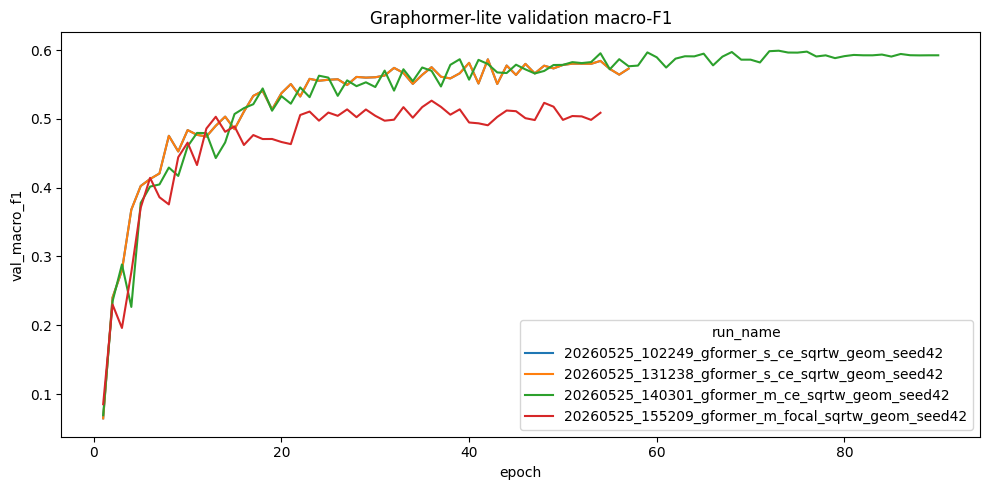

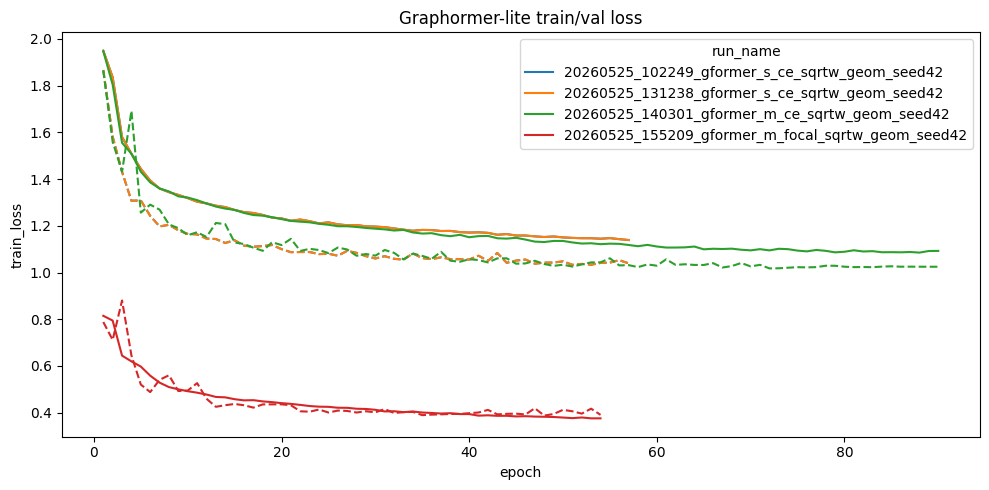

In [15]:
# Plot per-run training curves after the sweep.
history_frames = []
for run_dir in sorted(EXPERIMENTS_DIR.iterdir()):
    history_path = run_dir / "history.csv"
    if not history_path.exists():
        continue
    frame = pd.read_csv(history_path)
    frame["run_name"] = run_dir.name
    history_frames.append(frame)

if history_frames:
    history_df = pd.concat(history_frames, ignore_index=True)
    history_all_path = RESULTS_DIR / "graphormer_lite_all_history.csv"
    history_df.to_csv(history_all_path, index=False)
    print("saved:", history_all_path)

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="run_name")
    plt.title("Graphormer-lite validation macro-F1")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "graphormer_lite_val_macro_f1.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=history_df, x="epoch", y="train_loss", hue="run_name")
    sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="run_name", linestyle="--", legend=False)
    plt.title("Graphormer-lite train/val loss")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "graphormer_lite_loss_curves.png", dpi=160)
    plt.show()
else:
    print("No history files found yet. Run the sweep cell first.")


## Expected Artifacts

Main files after a completed run:

- `rafdb_graphormer_lite_full_run/results/graphormer_lite_comparison.csv`
- `rafdb_graphormer_lite_full_run/results/graphormer_lite_summaries.json`
- `rafdb_graphormer_lite_full_run/results/graphormer_lite_all_history.csv`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/history.csv`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/history.jsonl`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/best_model.pt`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/predictions_val.parquet`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/predictions_test.parquet`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/confusion_matrix_val.png`
- `rafdb_graphormer_lite_full_run/experiments/<timestamp>_<run>/confusion_matrix_test.png`
